<a href="https://colab.research.google.com/github/vad-source/NLPAPP/blob/main/DIALOGUE%5CNLPAPP_Rule_Based_Dialogue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NLP APPLICATIONS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

In [ ]:
#!pip install nltk spacy textblob scikit-learn pandas
#!python -m spacy download en_core_web_sm

In [ ]:
import re
import random
import spacy
from textblob import TextBlob
from collections import defaultdict

nlp = spacy.load("en_core_web_sm")

## **0 : Knowledge Base**

### Source Data

In [ ]:
FLIGHTS = {("bangalore", "delhi"): ["6AM", "10AM", "6PM"],("bangalore", "mumbai"): ["9AM", "3PM"],("delhi", "chennai"): ["11AM", "8PM"]
}

## **1 : Dialogue Processor**

#### **Memory**

In [ ]:
class Memory:
    def __init__(self):
        self.short_term = []
        self.long_term = {"preferred_airline": "Indigo"}
        self.episodic = []
memory = Memory()

#### Dialogue State

In [ ]:
dialogue_state = {
    "intent": None,
    "source": None,
    "destination": None,
    "date": None,
    "time": None,
    "passenger_name": None,
    "confirmed": False
}

###**1.1 NLU**
Conversation Processor

#### Intent Classifier
* Rule Based

In [ ]:
#May be used for In-Context Learning"
few_shot_examples = [{"input": "Book flight Bangalore Delhi", "intent": "book_flight"},
    {"input": "Cancel ticket","intent": "cancel"}
]

In [ ]:
def identify_intent(text):
    text = text.lower()

    for ex in few_shot_examples:
      if ex["input"].lower() in text.lower():
          return ex["intent"]

    if any(x in text for x in ["book", "flight", "travel"]):
        return "book_flight"
    elif any(x in text for x in ["yes", "confirm"]):
        return "confirm_booking"
    elif any(x in text for x in ["cancel"]):
        return "cancel"
    return "unknown"

#### NER (Slot Filling)

In [ ]:
def extract_slots(text):
    slots = {}
    doc = nlp(text)
    cities = ["bangalore", "delhi", "mumbai", "chennai"]
    for token in doc:
        if token.text.lower() in cities:
            if not dialogue_state["source"]:
                slots["source"] = token.text.lower()
            else:
                slots["destination"] = token.text.lower()

    # Feature 1 extraction
    date_match = re.search(r"(tomorrow|today|\d{1,2}/\d{1,2}/\d{2,4})", text.lower())
    if date_match:
        slots["date"] = date_match.group()

    # Feature 2 extraction
    time_match = re.search(r"(\d{1,2}(am|pm))", text.lower())
    if time_match:
        slots["time"] = time_match.group()

    # PERSON NER
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            slots["passenger_name"] = ent.text

    return slots

### **1.2 Dialogue Manager**

#### CoReference Resolution

In [ ]:
def resolve_coreference(text):
    if "there" in text.lower():
        if dialogue_state["destination"]:
            text = text.replace("there", dialogue_state["destination"])
    return text

#### Policy Management

In [ ]:
reward_score = 0
policy_memory = {"clarification_needed": False,"politeness_level": 1}

In [ ]:
def next_action():
    global reward_score
    required_slots = ["source", "destination", "date"]
    for slot in required_slots:
        if dialogue_state[slot] is None:
            # RLHF adaptation
            if reward_score < -10:
                policy_memory["clarification_needed"] = True
                return f"clarify_{slot}"
            return f"ask_{slot}"
    return "confirm"

### **1.3 Memory Manager**
Memory/Context/State Tracker

In [ ]:
def update_state(intent, slots):
    dialogue_state["intent"] = intent
    for k, v in slots.items():
        dialogue_state[k] = v

### **1.4 Other Helper Functions**

In [ ]:
def sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    return "neutral"

In [ ]:
def reset_system():
    global dialogue_state
    global memory
    global feedback_log
    dialogue_state = {"intent": None, "source": None,"destination": None,"date": None,"time": None,"passenger_name": None, "confirmed": False
    }
    memory = Memory()
    feedback_log = []
    print("System reset complete.")

## **2 : Document Processor**

## **3 : Retriever/ Reasoner**

## **4 : Generator**
Response Generation NLG

In [ ]:
def generate_response (action,user_sentiment, SYSTEM_INSTRUCTIONS ):

    #Instruction Tuning. This is not relevant here . In LLM based agent this becomes a part of prompt
    SYSTEM_INSTRUCTIONS_Sample = """
    You are a polite airline assistant.

    Rules:
    1. Always ask clarification if slots missing
    2. Never hallucinate flights
    3. Maintain context
    4. Be concise
    """

    if action == "ask_source":
        if SYSTEM_INSTRUCTIONS["tone"] == "polite":
            return ("Certainly! Could you please tell me which city you are travelling from?")
        return "Source city?"
    elif action == "clarify_source":
        return "I'm sorry for the confusion earlier. Could you please tell me your departure city?"
    elif action == "ask_destination":
        return "Where would you like to travel?"
    elif action == "ask_date":
        return "What date would you like to travel?"

    elif action == "confirm":
        flights = FLIGHTS.get((dialogue_state["source"], dialogue_state["destination"]),[])
        if SYSTEM_INSTRUCTIONS["hallucination_control"]:
            if not flights:
                return "I could not find verified flights for this route."
        return (f"I found flights from {dialogue_state['source']} "f"to {dialogue_state['destination']} on "
            f"{dialogue_state['date']}. "f"Available times: {flights}. "f"Would you like to confirm?")
    if user_sentiment == "negative":
        if SYSTEM_INSTRUCTIONS["empathetic_mode"]:
            return "I understand this may be frustrating.Let me help you."
    return "Sorry, I didn't understand."

In [ ]:
def task_success():
    required = ["source", "destination", "date"]
    return all(dialogue_state[x] for x in required)

## **5 : Response Processor(Validation)**

In [ ]:
def adjacency_pair_valid(user_text, system_response):
    if "?" in system_response:
        return True
    return False

## **6 : Evaluator**

In [ ]:
evaluation_logs = {"intent_predictions": [],"slot_predictions": [], "coreference_results": [],"adjacency_pairs": [],
    "generation_quality": [], "feedback_scores": []}

In [ ]:
evaluation_data = [
     {"input": "Book flight from Bangalore to Delhi tomorrow","intent": "book_flight", "slots": {"source": "bangalore",
            "destination": "delhi","date": "tomorrow"}},
    { "input": "Cancel my booking","intent": "cancel","slots": {} }
]

In [ ]:
def evaluate_intent_accuracy():
    total = len(evaluation_logs["intent_predictions"])
    if total == 0:
        print("Intent Accuracy: No data")
        return
    correct = 0
    # Simulated ground truth
    for item in evaluation_logs["intent_predictions"]:
        predicted = item["predicted_intent"]
        # simplistic evaluation
        if predicted != "unknown":
            correct += 1
    accuracy = correct / total
    print(f"Intent Accuracy: {accuracy:.2f}")

In [ ]:
def evaluate_intent_accuracy_TODO():
    total = len(evaluation_logs["intent_predictions"])
    if total == 0:
        print("Intent Accuracy: No data")
        return
    correct = 0
    for item in evaluation_logs["intent_predictions"]:
        predicted = item["predicted_intent"]
        ground_truth = item["ground_truth"]
        if predicted == ground_truth:
            correct += 1
    accuracy = correct / total
    print(f"Intent Accuracy: {accuracy:.2f}")

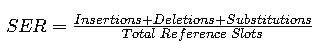

In [ ]:
def evaluate_slot_filling_simple():
    total_insertions = 0
    total_deletions = 0
    total_substitutions = 0
    total_reference_slots = 0
    for item in evaluation_data:
        predicted = extract_slots(item["input"])
        reference = item["slots"]
        total_reference_slots += len(reference)
        for slot in reference:
            if slot not in predicted:
                total_deletions += 1
            elif predicted[slot] != reference[slot]:
                total_substitutions += 1
        for slot in predicted:
            if slot not in reference:
                total_insertions += 1
    ser = (total_insertions + total_deletions + total_substitutions) / total_reference_slots
    print("Slot Error Rate:", ser)

In [ ]:
def evaluate_slot_filling():
    total_slots = 0
    extracted_slots = 0
    for item in evaluation_logs["slot_predictions"]:
        slots = item["predicted_slots"]
        total_slots += 3
        extracted_slots += len(slots)
    ser = 1 - (extracted_slots / total_slots)
    print(f"Slot Error Rate (SER): {ser:.2f}")

In [ ]:
coreference_tests = [{"context_destination": "delhi","input": "I want to go there",  "expected": "I want to go delhi"}]

def evaluate_coreference_old():
    correct = 0
    for test in coreference_tests:
        dialogue_state["destination"] = test["context_destination"]
        resolved = resolve_coreference(test["input"])
        if resolved.lower() == test["expected"].lower():
            correct += 1
    print("Coreference Accuracy:",
          correct / len(coreference_tests))

In [ ]:
def evaluate_coreference():
    total = len(evaluation_logs["coreference_results"])
    if total == 0:
        print("Coreference Score: No data")
        return
    resolved = 0
    for item in evaluation_logs["coreference_results"]:
        if item["original"] != item["resolved"]:
            resolved += 1
    score = resolved / total
    print(f"Coreference Resolution Score: {score:.2f}")

In [ ]:
adjacency_score = []
def evaluate_adjacency_pairs_old(system_response):
    if "?" in system_response:
        adjacency_score.append(1)
    else:
        adjacency_score.append(0)

def adjacency_result():
    print("Adjacency Pair Score:", sum(adjacency_score)/len(adjacency_score))

In [ ]:
def evaluate_adjacency_pairs():
    total = len(evaluation_logs["adjacency_pairs"])
    if total == 0:
        print("Adjacency Pair Score: No data")
        return
    coherent = 0
    for pair in evaluation_logs["adjacency_pairs"]:
        response = pair["system"]
        if len(response) > 0:
            coherent += 1
    score = coherent / total
    print(f"Adjacency Pair Score: {score:.2f}")

In [ ]:
def evaluate_generation_quality():
    total = len(evaluation_logs["generation_quality"])
    if total == 0:
        print("Generation Quality: No data")
        return
    avg_length = 0
    for item in evaluation_logs["generation_quality"]:
        avg_length += item["length"]
    avg_length /= total
    print(f"Average Response Length: {avg_length:.2f}")

In [ ]:
task_results = []
def evaluate_task_success_rate_old():
    success = sum(task_results)
    total = len(task_results)
    if total == 0:
        return
    print("Task Success Rate:", success / total)

In [ ]:
def evaluate_task_success_rate():
    required_slots = [ "source","destination","date"]
    success = all(dialogue_state[x] for x in required_slots)
    print(f"Task Success: {success}")

In [ ]:
def evaluate_feedback_old():
    avg = sum(feedback_log) / len(feedback_log)
    print("Average User Feedback:", avg)

In [ ]:
def evaluate_feedback():
    scores = evaluation_logs["feedback_scores"]
    if len(scores) == 0:
        print("User Feedback Score: No feedback")
        return
    avg = sum(scores) / len(scores)
    print(f"Average User Feedback: {avg:.2f}/5")

In [ ]:
def Immediate_User_score(feedback):
  global reward_score
  if feedback >= 4:
      reward_score += 4
  elif feedback == 3:
      reward_score += 0
  else:
      reward_score -= 2
  return

In [ ]:
def run_full_evaluation():
    print("\n")
    print("========================================")
    print(" CONVERSATIONAL AI EVALUATION REPORT ")
    print("========================================")
    #evaluate_intent_accuracy()
    evaluate_slot_filling()
    evaluate_coreference()
    evaluate_adjacency_pairs()
    evaluate_generation_quality()
    evaluate_feedback()
    evaluate_task_success_rate()
    print("========================================")

## **Pipeline**

In [ ]:
def chatbot(SYSTEM_INSTRUCTIONS):
    print("TravelBot: Hello! How can I help you today?")


    while True:
        user_input = input("User: ")
        if user_input.lower() == "exit":
            break

        # memory
        memory.short_term.append(user_input)

        # coreference
        resolved = resolve_coreference(user_input)
        evaluation_logs["coreference_results"].append({"original": user_input,"resolved": resolved})

        # NLU
        intent = identify_intent(resolved)
        evaluation_logs["intent_predictions"].append({"input": user_input,"predicted_intent": intent})
        #evaluation_logs["intent_predictions"].append({"input": user_input,"intent": intent})
        #evaluation_logs["intent_predictions"].append({"input": user_input, "ground_truth": "book_flight", "predicted_intent": intent})
        slots = extract_slots(resolved)
        evaluation_logs["slot_predictions"].append({"input": user_input,"predicted_slots": slots})

        # state tracking
        update_state(intent, slots)

        # sentiment
        user_sentiment = sentiment(user_input)

        # policy
        action = next_action()

        # response generation
        response = generate_response(action, user_sentiment,SYSTEM_INSTRUCTIONS)
        #evaluate_adjacency(response)
        evaluation_logs["adjacency_pairs"].append({"user": user_input,"system": response})
        evaluation_logs["generation_quality"].append({"response": response,"length": len(response.split()),"coherent": True})

        #Human Relevance Score
        #feedback = int(input("Rate response (1-5): "))
        #feedback_log.append(int(feedback))
        #Immediate_User_score(int(feedback))

        # episodic memory
        memory.episodic.append({"user": user_input,"system": response})

        print(f"Bot: {response}")
        print(f"(Sentiment: {user_sentiment})")

        # success
        if task_success():
            task_results.append(task_success())
            print("Task Completed Successfully!")
            feedback = int(input("Please rate your overall experience (1-5): "))
            evaluation_logs["feedback_scores"].append(feedback)
            break

In [ ]:
SYSTEM_INSTRUCTIONS = {
    "tone": "polite",
    "clarification_strategy": True,
    "hallucination_control": True,
    "max_response_length": 2,
    "empathetic_mode": True
}

In [ ]:
reset_system()
chatbot(SYSTEM_INSTRUCTIONS)
run_full_evaluation()

System reset complete.
TravelBot: Hello! How can I help you today?
User: Book Ticket
Bot: Certainly! Could you please tell me which city you are travelling from?
(Sentiment: neutral)
User: Madurai
Bot: Certainly! Could you please tell me which city you are travelling from?
(Sentiment: neutral)
User: Madurai
Bot: Certainly! Could you please tell me which city you are travelling from?
(Sentiment: neutral)
User: BAD
Bot: Certainly! Could you please tell me which city you are travelling from?
(Sentiment: negative)
User: BAD
Bot: Certainly! Could you please tell me which city you are travelling from?
(Sentiment: negative)
User: Delhi
Bot: Where would you like to travel?
(Sentiment: neutral)
User: Dlehi
Bot: Where would you like to travel?
(Sentiment: neutral)
User: Delhi
Bot: What date would you like to travel?
(Sentiment: neutral)
User: Yesterday
Bot: What date would you like to travel?
(Sentiment: neutral)
User: Today
Bot: I could not find verified flights for this route.
(Sentiment: neut

In [ ]:
#If reset doesn't work run below
#import os
#os.kill(os.getpid(), 9)